In [1]:
# Activate Julia package
using Pkg
Pkg.activate("vSmartMOM_ISOP.jl")
Pkg.instantiate()

import Pkg; Pkg.add("Plots")

using Statistics, PlutoUI, Polynomials,  Plots, LazyArtifacts, LinearAlgebra, NCDatasets, Format
include("vSmartMOM_ISOP.jl/src/vSmartMOM.jl")
using .vSmartMOM, .vSmartMOM.Absorption
include("helper_functions.jl")
default(fontfamily="Helvetica");

  Activating project at `~/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl`
┌ Warning: The project dependencies or compat requirements have changed since the manifest was last resolved.
│ It is recommended to `Pkg.resolve()` or consider `Pkg.update()` if necessary.
└ @ Pkg.API /Users/jamesyoon/.julia/juliaup/julia-1.11.3+0.aarch64.apple.darwin14/share/julia/stdlib/v1.11/Pkg/src/API.jl:1206
Precompiling project...
   6852.0 ms  ✓ vSmartMOM
  1 dependency successfully precompiled in 9 seconds. 382 already precompiled.
  1 dependency had output during precompilation:
┌ vSmartMOM
│  WARNING: method definition for elemental! at /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/CoreKernel/elemental_canopy.jl:7 declares type variable M but does not use it.
│  WARNING: method definition for interaction_hdrf! at /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM_ISOP.jl/src/CoreRT/CoreKernel/interaction_hdrf.jl:9 declares type variable FT2 but does not use it.
│  WA

In [2]:
filepath = "HITRAN/c5h8_isoprene.101"
ν_min = 890.
ν_max = 910.

isoprene_hitran = vSmartMOM.Absorption.read_hitran_isoprene(filepath, ν_min = ν_min, ν_max = ν_max);

lineModel = vSmartMOM.Absorption.Voigt()
isoprene_voigt = vSmartMOM.make_hitran_model(isoprene_hitran, lineModel, wing_cutoff=10, architecture=vSmartMOM.CPU());
hitran_array = [isoprene_voigt];

In [3]:
date = "20190701"
startTime = "06z" # 00, 06, 12 or 18 in UTC, i.e. 6 hourly data stacked together

lat = 2.
lon = 100.

# Here, we download a reanalysis file from MERRA (NASA), these files are huge (500Mb), so it might take a file. We are using JULIA tools again, usually you will have to download these yourself:
MerraFile = "MERRA2_400.inst6_3d_ana_Nv." * date * ".nc4"
MerraFolder = "MERRA2/"
MF = joinpath(MerraFolder, MerraFile)
profile_hr = read_atmos_profile(MF, lat, lon, 4);

ds["T"] = T (576 × 361 × 72 × 4)
  Datatype:    Union{Missing, Float32} (Float32)
  Dimensions:  lon × lat × lev × time
  Attributes:
   long_name            = Air temperature
   units                = K
   _FillValue           = 1.0e15
   missing_value        = 1.0e15
   fmissing_value       = 1.0e15
   scale_factor         = 1.0
   add_offset           = 0.0
   standard_name        = air_temperature
   vmax                 = 1.0e15
   vmin                 = -1.0e15
   valid_range          = Float32[-1.0f15, 1.0f15]



In [4]:
res = 0.06
ν_grid = ν_min:res:ν_max
pressures = profile_hr.p
temperatures = profile_hr.T

model_interp = compute_profile_crossSections_isoprene(profile_hr, hitran_array, ν_grid);

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194


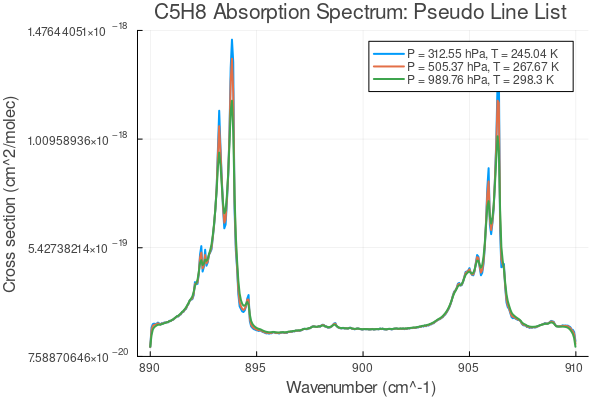

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194


In [5]:
index = 45
plot(ν_grid, model_interp[:,index,1],
    title = "C5H8 Absorption Spectrum: Pseudo Line List", label = "P = $(round(pressures[index] / 100, digits = 2)) hPa, T = $(round(temperatures[index], digits = 2)) K", lw = 2)

index = 50
plot!(ν_grid, model_interp[:,index,1],
    label = "P = $(round(pressures[index] / 100, digits = 2)) hPa, T = $(round(temperatures[index], digits = 2)) K", lw = 2)

index = 72
plot!(ν_grid, model_interp[:,index,1],
    label = "P = $(round(pressures[index] / 100, digits = 2)) hPa, T = $(round(temperatures[index], digits = 2)) K", lw = 2)

ylabel!("Cross section (cm^2/molec)")
xlabel!("Wavenumber (cm^-1)")

## Compare Voigt-broadened absorption spectra with PNNL spectra

In [6]:
resolution = (6499.9532 - 599.9943) / 97909 # 97902
nu = collect(599.9943:resolution:6499.9532)

experimental_278 = vec(readdlm("HITRAN/C5-H8_278.1K-760.0K_600.0-6500.0_0.11_N2_505_43.xsc.txt", ' ')[:,2:end]');
experimental_298 = vec(readdlm("HITRAN/C5-H8_298.1K-760.0K_600.0-6500.0_0.11_N2_505_43.xsc.txt", ' ')[:,2:end]');
experimental_323 = vec(readdlm("HITRAN/C5-H8_323.1K-760.0K_600.0-6500.0_0.11_N2_505_43.xsc.txt", ' ')[:,2:end]');

# Modeled Spectra

modeled_spectra_278 = vSmartMOM.Absorption.absorption_cross_section_isoprene(isoprene_voigt, 
    ν_grid, 
    1013.25, 
    278.1)
compute_profile_crossSections_isoprene(profile_hr, hitran_array, ν_grid);

modeled_spectra_298 = vSmartMOM.Absorption.absorption_cross_section_isoprene(isoprene_voigt, 
    ν_grid, 
    1013.25, 
    298.1)
compute_profile_crossSections_isoprene(profile_hr, hitran_array, ν_grid);

modeled_spectra_323 = vSmartMOM.Absorption.absorption_cross_section_isoprene(isoprene_voigt, 
    ν_grid, 
    1013.25, 
    323.1)
compute_profile_crossSections_isoprene(profile_hr, hitran_array, ν_grid);

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict

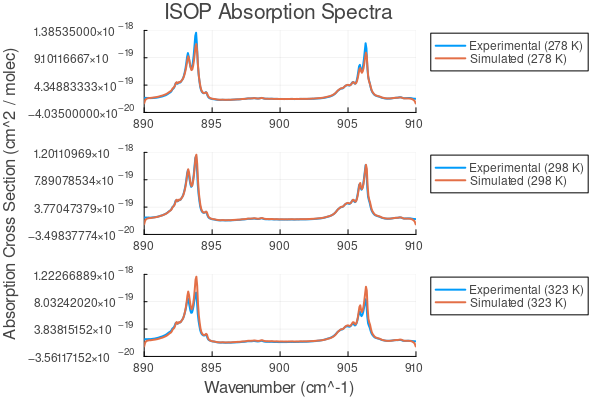

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/dVEMd/src/ticks.jl:194


In [10]:
p1 = plot(nu, experimental_278, xlimit = [890, 910], label = "Experimental (278 K)", lw = 2, legend = :outertopright)
plot!(ν_grid, modeled_spectra_278, xlimit = [890, 910], label = "Simulated (278 K)", lw = 2)
title!("ISOP Absorption Spectra")

p2 = plot(nu, experimental_298, xlimit = [890, 910], label = "Experimental (298 K)", lw = 2, legend = :outertopright)
plot!(ν_grid, modeled_spectra_298, xlimit = [890, 910], label = "Simulated (298 K)", lw = 2)
ylabel!("Absorption Cross Section (cm^2 / molec)")

p3 = plot(nu, experimental_323, xlimit = [890, 910], label = "Experimental (323 K)", lw = 2, legend = :outertopright)
plot!(ν_grid, modeled_spectra_323, xlimit = [890, 910], label = "Simulated (323 K)", lw = 2)
xlabel!("Wavenumber (cm^-1)")
plot(p1, p2, p3, layout = (3,1))